In [38]:
import sys
import os

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.append(project_root)

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [39]:
from datapipeline.utils.spark_session import get_spark_session
spark = get_spark_session("Analytics_Dashboard")

In [40]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [41]:
analytics_base = os.path.join(project_root, "sanewsstorage/analytics")

topic_daily = spark.read.format("delta").load(os.path.join(analytics_base, "topic_daily"))
topic_summary = spark.read.format("delta").load(os.path.join(analytics_base, "topic_summary"))
event_snapshot = spark.read.format("delta").load(os.path.join(analytics_base, "event_snapshot"))
entity_snapshot = spark.read.format("delta").load(os.path.join(analytics_base, "entity_snapshot"))
search_index = spark.read.format("delta").load(os.path.join(analytics_base, "search_index"))

In [42]:
print("\n================ GLOBAL SITUATION OVERVIEW ================\n")

total_topics = topic_summary.count()
hot_topics = topic_summary.filter(F.col("is_hot") == 1).count()
active_events = event_snapshot.count()

print(f"Total Active Topics: {total_topics}")
print(f"Hot Topics (Spiking or Event): {hot_topics}")
print(f"Active Events: {active_events}")


================ GLOBAL SITUATION OVERVIEW ================

Total Active Topics: 19
Hot Topics (Spiking or Event): 0
Active Events: 0


In [43]:
top_topics = (
    topic_summary
    .orderBy(F.desc("today_volume"))
    .limit(10)
    .toPandas()
)

print("\nMost Covered Topics Today:\n")

for _, row in top_topics.iterrows():
    print(f"• {row['cluster_label']}")
    print(f"  Volume: {row['today_volume']}")
    print(f"  Event Type: {row['event_type']}")
    print("-" * 50)


Most Covered Topics Today:

• Allegany Munetaka Murakami Murakami Baker Mayfield
  Volume: 111
  Event Type: Emerging
--------------------------------------------------
• Devin Strader Peter Greene Wand
  Volume: 101
  Event Type: Emerging
--------------------------------------------------
• Hansi Flick Госдепа США Линдси Вонн
  Volume: 78
  Event Type: Emerging
--------------------------------------------------
• LLC Makes New Corrects Paolo Ardoino
  Volume: 75
  Event Type: Trending
--------------------------------------------------
• Trump Policy Republikanie Hawanę
  Volume: 72
  Event Type: Trending
--------------------------------------------------
• Portland Police В. Попов
  Volume: 68
  Event Type: Emerging
--------------------------------------------------
• Венгрию Еврокомиссии Esmaeil Baqaei
  Volume: 63
  Event Type: Emerging
--------------------------------------------------
• Lyra GZSZ Jinwoo
  Volume: 60
  Event Type: Emerging
-----------------------------------------

In [50]:
high_impact = (
    event_snapshot
    .orderBy(F.desc("event_score_peak"))
    .limit(5)
    .toPandas()
)

print("\nHigh Impact Events:\n")

for _, row in high_impact.iterrows():
    print(f"• {row['cluster_label']}")
    print(f"  Type: {row['event_type']}")
    print(f"  Duration: {row['duration_days']} days")
    print(f"  Peak Volume: {row['peak_volume']}")
    print("-" * 50)


High Impact Events:



c:\Users\Echelon\Desktop\re\sa-news\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2958 (\N{TAMIL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Echelon\Desktop\re\sa-news\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Echelon\Desktop\re\sa-news\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2975 (\N{TAMIL LETTER TTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Echelon\Desktop\re\sa-news\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3009 (\N{TAMIL VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Echelon\Desktop\re\sa-news\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) 

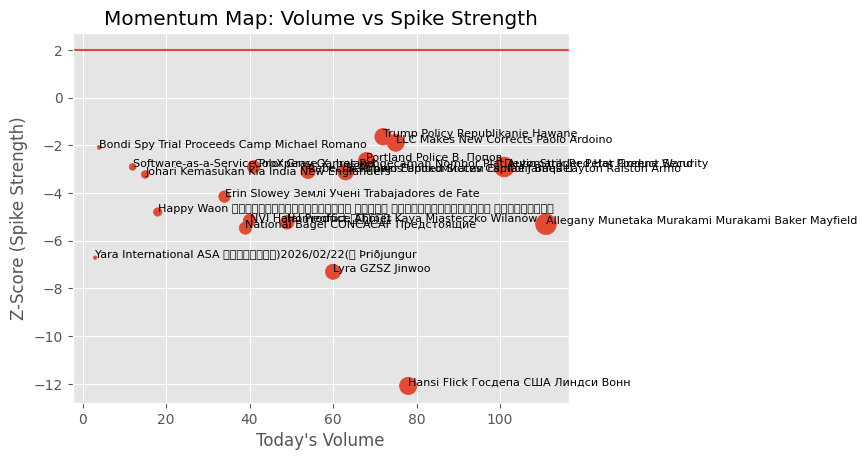

In [45]:
momentum_df = (
    topic_summary
    .select("cluster_label", "today_volume", "z_score")
    .orderBy(F.desc("z_score"))
    .limit(20)
    .toPandas()
)

plt.figure()
plt.scatter(
    momentum_df["today_volume"],
    momentum_df["z_score"],
    s=momentum_df["today_volume"] * 2
)

for i, txt in enumerate(momentum_df["cluster_label"]):
    plt.annotate(txt,
                 (momentum_df["today_volume"][i],
                  momentum_df["z_score"][i]),
                 fontsize=8)

plt.axhline(2)
plt.title("Momentum Map: Volume vs Spike Strength")
plt.xlabel("Today's Volume")
plt.ylabel("Z-Score (Spike Strength)")
plt.show()

In [49]:
top_clusters = (
    event_snapshot
    .orderBy(F.desc("event_score_peak"))
    .select("cluster_id", "cluster_label")
    .limit(3)
    .collect()
)

for cluster in top_clusters:
    history = (
        topic_daily
        .filter(F.col("cluster_id") == cluster["cluster_id"])
        .orderBy("date")
        .select("date", "article_count")
        .toPandas()
    )

    plt.figure()
    plt.plot(history["date"], history["article_count"])
    plt.title(f"Coverage Trend — {cluster['cluster_label']}")
    plt.xlabel("Date")
    plt.ylabel("Article Count")
    plt.xticks(rotation=45)
    plt.show()

In [47]:
top_entities = (
    entity_snapshot
    .orderBy(F.desc("growth_signal"))
    .limit(10)
    .toPandas()
)

print("\n👤 Fastest Growing Entities:\n")

for _, row in top_entities.iterrows():
    print(f"• {row['entity_name']}")
    print(f"  7d Mentions: {row['mentions_7d']}")
    print(f"  24h Mentions: {row['mentions_24h']}")
    print(f"  Growth Signal: {round(row['growth_signal'],2)}")
    print("-" * 50)


👤 Fastest Growing Entities:

• England
  7d Mentions: 130
  24h Mentions: 0
  Growth Signal: 0.0
--------------------------------------------------
• Follow the
  7d Mentions: 1
  24h Mentions: 0
  Growth Signal: 0.0
--------------------------------------------------
• Murrayfield
  7d Mentions: 1
  24h Mentions: 0
  Growth Signal: 0.0
--------------------------------------------------
• China
  7d Mentions: 416
  24h Mentions: 0
  Growth Signal: 0.0
--------------------------------------------------
• Six Nations
  7d Mentions: 18
  24h Mentions: 0
  Growth Signal: 0.0
--------------------------------------------------
• Dynamite Entertainment
  7d Mentions: 4
  24h Mentions: 0
  Growth Signal: 0.0
--------------------------------------------------
• As the U.S.
  7d Mentions: 1
  24h Mentions: 0
  Growth Signal: 0.0
--------------------------------------------------
• Discovery Global Consumer Products
  7d Mentions: 1
  24h Mentions: 0
  Growth Signal: 0.0
-------------------------

In [48]:
def search_articles(keyword=None):

    df = search_index

    if keyword:
        df = df.filter(F.lower(F.col("title")).contains(keyword.lower()))

    results = df.orderBy(F.desc("published_at")).limit(10).toPandas()

    print("\n================ SEARCH RESULTS ================\n")

    if results.empty:
        print("No results found.\n")
        return

    for _, row in results.iterrows():
        print(f"• {row['title']}")
        print(f"  Published: {row['published_at']}")
        print("-" * 60)

search_articles("tariff")


================ SEARCH RESULTS ================

• Why did Donald Trump impose 50% tariff on India? Explains US Senator, says PM Modi...
  Published: 2026-02-22 12:07:04
------------------------------------------------------------
• Neal Katyal: Indian-origin American lawyer who dealt major blow to Trump 2.0’s tariff agenda
  Published: 2026-02-22 12:07:02
------------------------------------------------------------
• What happens to the tariff revenue now? #politics
  Published: 2026-02-22 12:07:00
------------------------------------------------------------
• Trump Pulls Support From House Republican Who Opposed Tariffs - The New York Times
  Published: 2026-02-22 09:03:49
------------------------------------------------------------
• Trump says he will raise global tariffs to 15% after Supreme Court decision - CBS News
  Published: 2026-02-22 09:03:38
------------------------------------------------------------
• Trump to raise US global tariff from 10 to 15% after Supreme Court r

In [22]:
spark.stop()